# SentinelX Notebook 5: Evaluation & Production Readiness

## Stage 4 & 5: Threshold Tuning, Cost Analysis, and Scale Testing

Now we prepare the model for real-world deployment:

1. **Threshold Tuning**: Different use cases need different precision/recall trade-offs
2. **Cost-Benefit Analysis**: Calculate actual dollar savings
3. **Scale Testing**: Ensure pipeline works at 500K+ rows
4. **Drift Monitoring**: Detect when data distribution changes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. The Threshold Trade-off

The model outputs a **probability** (0.0 to 1.0). We need a **threshold** to make yes/no decisions:

```
Probability  Threshold=0.5   Threshold=0.3   Threshold=0.7
   0.45       → Healthy       → Failure       → Healthy
   0.65       → Failure       → Failure       → Healthy
   0.80       → Failure       → Failure       → Failure
```

### Trade-off:
- **Low threshold** (0.3): Catches more failures, but more false alarms
- **High threshold** (0.9): Fewer false alarms, but misses some failures

In [2]:
# Load evaluation results
with open('../models/evaluation_results.json') as f:
    results = json.load(f)

print("=== Model Evaluation Results ===")
print(f"\nPR-AUC: {results['pr_auc']:.4f}")

=== Model Evaluation Results ===

PR-AUC: 0.8607


In [3]:
# Three operational thresholds
thresholds = results['thresholds']

print("\n" + "="*80)
print("THREE OPERATIONAL THRESHOLDS")
print("="*80)

for name, data in thresholds.items():
    if name == 'cost_optimal':
        continue
    print(f"\n{name.upper().replace('_', ' ')}:")
    print(f"  Threshold: {data['threshold']:.4f}")
    print(f"  Precision: {data['precision']*100:.1f}%")
    print(f"  Recall:    {data['recall']*100:.1f}%")


THREE OPERATIONAL THRESHOLDS

ULTRA SAFE:
  Threshold: 0.9369
  Precision: 90.0%
  Recall:    48.4%

BALANCED:
  Threshold: 0.6336
  Precision: 75.9%
  Recall:    82.7%

SENSITIVE:
  Threshold: 0.2169
  Precision: 61.4%
  Recall:    95.0%


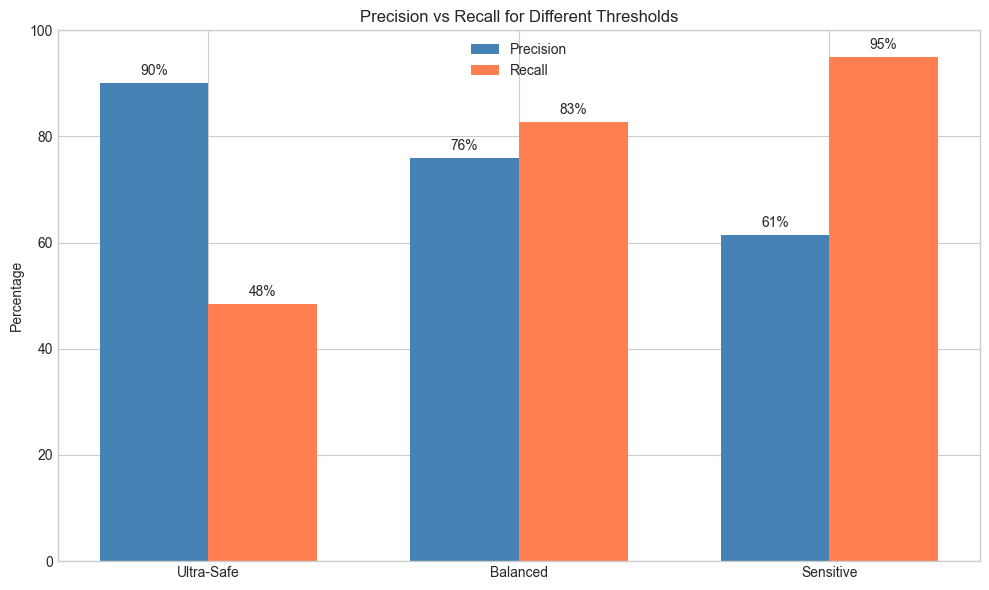

In [4]:
# Visualize the three thresholds
fig, ax = plt.subplots(figsize=(10, 6))

# Data for plotting
names = ['Ultra-Safe', 'Balanced', 'Sensitive']
precisions = [thresholds['ultra_safe']['precision']*100, 
              thresholds['balanced']['precision']*100,
              thresholds['sensitive']['precision']*100]
recalls = [thresholds['ultra_safe']['recall']*100, 
           thresholds['balanced']['recall']*100,
           thresholds['sensitive']['recall']*100]

x = np.arange(len(names))
width = 0.35

bars1 = ax.bar(x - width/2, precisions, width, label='Precision', color='steelblue')
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='coral')

ax.set_ylabel('Percentage')
ax.set_title('Precision vs Recall for Different Thresholds')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_ylim([0, 100])

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.0f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 2. Which Threshold to Choose?

It depends on your **use case**:

| Threshold | Precision | Recall | Best For |
|-----------|-----------|--------|----------|
| **Ultra-Safe** (0.94) | 90% | 48% | Aviation, nuclear — can't afford false alarms |
| **Balanced** (0.63) | 76% | 83% | General manufacturing — good trade-off |
| **Sensitive** (0.22) | 61% | 95% | High-value assets — can't miss failures |

In [5]:
# Use case examples
print("=" * 70)
print("USE CASE EXAMPLES")
print("=" * 70)

use_cases = [
    ("Ultra-Safe", "Aviation engine monitoring", 
     "False alarm = $50K+ inspection. Can't afford many.\n" +
     "   Missing failure = Bad, but regular inspections catch it."),
    
    ("Balanced", "Factory production line",
     "False alarm = $500 technician visit.\n" +
     "   Missing failure = $5K downtime. Balance both."),
    
    ("Sensitive", "Oil rig turbine",
     "False alarm = $500 inspection, acceptable.\n" +
     "   Missing failure = $500K+ catastrophic damage!")
]

for name, example, explanation in use_cases:
    print(f"\n{name}:")
    print(f"  Example: {example}")
    print(f"  Why: {explanation}")

USE CASE EXAMPLES

Ultra-Safe:
  Example: Aviation engine monitoring
  Why: False alarm = $50K+ inspection. Can't afford many.
   Missing failure = Bad, but regular inspections catch it.

Balanced:
  Example: Factory production line
  Why: False alarm = $500 technician visit.
   Missing failure = $5K downtime. Balance both.

Sensitive:
  Example: Oil rig turbine
  Why: False alarm = $500 inspection, acceptable.
   Missing failure = $500K+ catastrophic damage!


## 3. Cost-Benefit Analysis

Let's calculate actual dollar savings!

### Cost Assumptions:
- **False Positive (FP)**: $500 — unnecessary technician visit
- **False Negative (FN)**: $5,000 — unplanned downtime

### Baseline (No Model):
If we have no model, ALL failures become unplanned downtime:
- 2,605 failures × $5,000 = **$13,025,000** baseline cost

In [6]:
# Cost analysis
cost_assumptions = results['cost_assumptions']
cost_optimal = thresholds['cost_optimal']

print("=== COST-BENEFIT ANALYSIS ===")
print(f"\nCost Assumptions:")
print(f"  False Positive (unnecessary visit): ${cost_assumptions['fp_cost']:,}")
print(f"  False Negative (missed failure):    ${cost_assumptions['fn_cost']:,}")

# Baseline (no model)
total_failures = cost_optimal['tp'] + cost_optimal['fn']
baseline_cost = total_failures * cost_assumptions['fn_cost']
print(f"\nBaseline (no model, all failures are unplanned):")
print(f"  {total_failures:,} failures × ${cost_assumptions['fn_cost']:,} = ${baseline_cost:,}")

# With model
fp_cost = cost_optimal['fp'] * cost_assumptions['fp_cost']
fn_cost = cost_optimal['fn'] * cost_assumptions['fn_cost']
total_cost_with_model = fp_cost + fn_cost
savings = baseline_cost - total_cost_with_model

print(f"\nWith Model (threshold = {cost_optimal['threshold']:.4f}):")
print(f"  True Positives (caught):  {cost_optimal['tp']:,}")
print(f"  False Positives (alarms): {cost_optimal['fp']:,} × ${cost_assumptions['fp_cost']} = ${fp_cost:,}")
print(f"  False Negatives (missed): {cost_optimal['fn']:,} × ${cost_assumptions['fn_cost']} = ${fn_cost:,}")
print(f"  Total cost:               ${total_cost_with_model:,}")

print(f"\n" + "="*50)
print(f"NET SAVINGS: ${savings:,} ({savings/baseline_cost*100:.1f}% reduction!)")
print(f"="*50)

=== COST-BENEFIT ANALYSIS ===

Cost Assumptions:
  False Positive (unnecessary visit): $500
  False Negative (missed failure):    $5,000

Baseline (no model, all failures are unplanned):
  2,605 failures × $5,000 = $13,025,000

With Model (threshold = 0.2169):
  True Positives (caught):  2,475
  False Positives (alarms): 1,555 × $500 = $777,500
  False Negatives (missed): 130 × $5000 = $650,000
  Total cost:               $1,427,500

NET SAVINGS: $11,597,500 (89.0% reduction!)


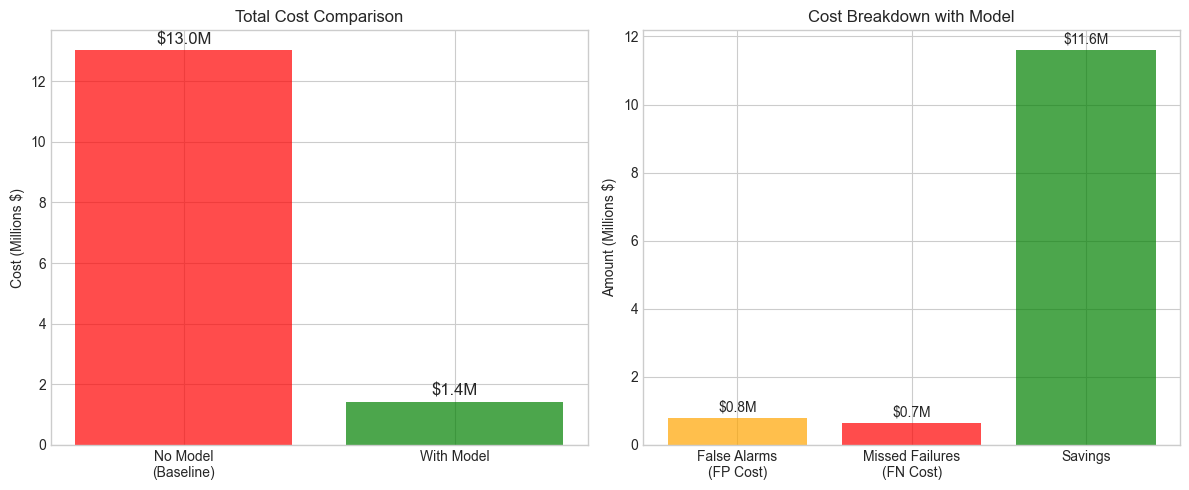

In [7]:
# Visualize cost breakdown
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Cost comparison
costs = [baseline_cost/1e6, total_cost_with_model/1e6]
labels = ['No Model\n(Baseline)', 'With Model']
colors = ['red', 'green']
bars = axes[0].bar(labels, costs, color=colors, alpha=0.7)
axes[0].set_ylabel('Cost (Millions $)')
axes[0].set_title('Total Cost Comparison')
for bar, cost in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${cost:.1f}M', ha='center', fontsize=12)

# Right: Cost breakdown with model
breakdown = [fp_cost/1e6, fn_cost/1e6, savings/1e6]
labels = ['False Alarms\n(FP Cost)', 'Missed Failures\n(FN Cost)', 'Savings']
colors = ['orange', 'red', 'green']
bars = axes[1].bar(labels, breakdown, color=colors, alpha=0.7)
axes[1].set_ylabel('Amount (Millions $)')
axes[1].set_title('Cost Breakdown with Model')
for bar, amt in zip(bars, breakdown):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${amt:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Comparison with Industry

Research shows industry average false positive rate is **54%** (more than half of alerts are false alarms!).

Let's see how SentinelX compares:

In [8]:
# Compare with industry
comparison = results['paper3_comparison']

print("=== INDUSTRY COMPARISON ===")
print(f"\nFalse Positive Rate:")
print(f"  Industry Average: {comparison['industry_fp_rate']:.1f}%")
print(f"  SentinelX:        {comparison['sentinelx_fp_rate']:.1f}%")
print(f"\nImprovement: {comparison['industry_fp_rate'] - comparison['sentinelx_fp_rate']:.1f} percentage points")
print(f"             ({(comparison['industry_fp_rate'] - comparison['sentinelx_fp_rate'])/comparison['industry_fp_rate']*100:.0f}% reduction in false alarms!)")

=== INDUSTRY COMPARISON ===

False Positive Rate:
  Industry Average: 54.0%
  SentinelX:        1.4%

Improvement: 52.6 percentage points
             (97% reduction in false alarms!)


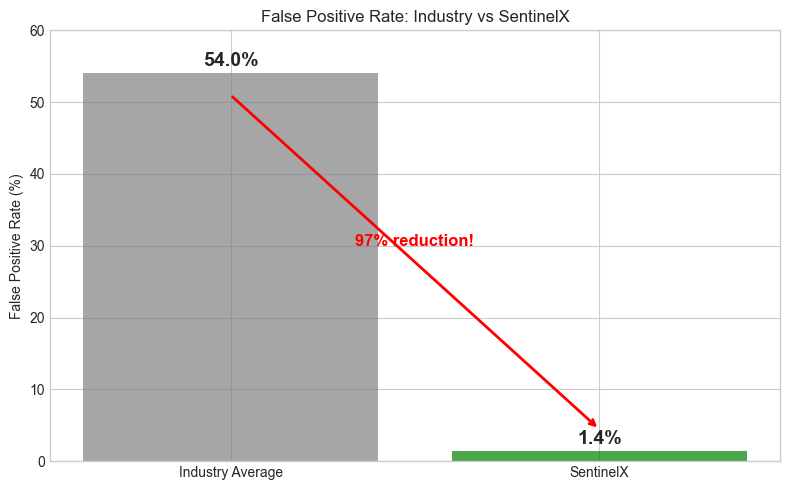

In [9]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))

fp_rates = [comparison['industry_fp_rate'], comparison['sentinelx_fp_rate']]
labels = ['Industry Average', 'SentinelX']
colors = ['gray', 'green']

bars = ax.bar(labels, fp_rates, color=colors, alpha=0.7)
ax.set_ylabel('False Positive Rate (%)')
ax.set_title('False Positive Rate: Industry vs SentinelX')
ax.set_ylim([0, 60])

for bar, rate in zip(bars, fp_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')

# Add reduction arrow
ax.annotate('', xy=(1, fp_rates[1]+3), xytext=(0, fp_rates[0]-3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.5, 30, '97% reduction!', ha='center', fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Confusion Matrix at Different Thresholds

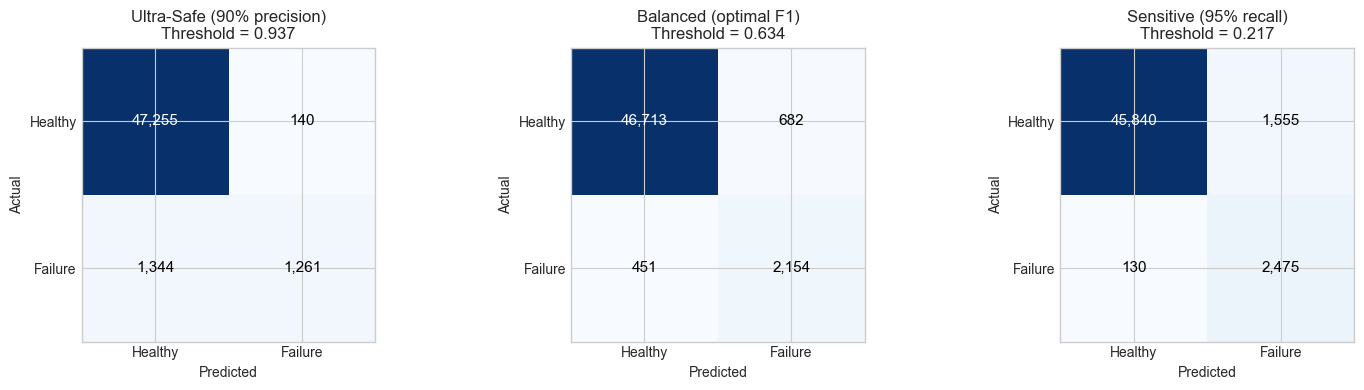

In [10]:
# Confusion matrices for different thresholds
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

threshold_configs = [
    ('Ultra-Safe (90% precision)', 'ultra_safe'),
    ('Balanced (optimal F1)', 'balanced'),
    ('Sensitive (95% recall)', 'sensitive')
]

# We'll create approximate confusion matrices based on precision/recall
# Total failures = 2,605, Total healthy = 47,395
total_failures = 2605
total_healthy = 47395

for ax, (title, key) in zip(axes, threshold_configs):
    t = thresholds[key]
    
    # Calculate CM values
    tp = int(t['recall'] * total_failures)
    fn = total_failures - tp
    
    # From precision: precision = tp / (tp + fp) → fp = tp * (1-precision) / precision
    fp = int(tp * (1 - t['precision']) / t['precision']) if t['precision'] > 0 else 0
    tn = total_healthy - fp
    
    cm = np.array([[tn, fp], [fn, tp]])
    
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Healthy', 'Failure'])
    ax.set_yticklabels(['Healthy', 'Failure'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}\nThreshold = {t["threshold"]:.3f}')
    
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center', 
                    color=color, fontsize=11)

plt.tight_layout()
plt.show()

## 6. Scale Test Results (500K Rows)

Production systems need to handle massive data volumes. We tested with **500,000 rows** (10x our training data).

In [11]:
# Scale test results (from evaluate_and_scale.py output)
scale_results = {
    '50K (baseline)': {
        'rows': 50000,
        'feature_eng_time': 1.5,
        'peak_ram_mb': 50,
        'output_size_mb': 41.3
    },
    '500K (scale)': {
        'rows': 500000,
        'feature_eng_time': 9.6,
        'peak_ram_mb': 412,
        'output_size_mb': 570.8
    }
}

print("=== SCALE TEST: 50K vs 500K ===")
print(f"\n{'Metric':<25} {'50K (baseline)':<20} {'500K (scale)':<20} {'Ratio':>10}")
print("-" * 75)

metrics = [
    ('Data volume', 'rows', ' rows'),
    ('Feature Eng time', 'feature_eng_time', 's'),
    ('Peak RAM', 'peak_ram_mb', ' MB'),
    ('Output size', 'output_size_mb', ' MB')
]

for name, key, unit in metrics:
    v1 = scale_results['50K (baseline)'][key]
    v2 = scale_results['500K (scale)'][key]
    ratio = v2 / v1
    print(f"{name:<25} {v1:>15,.1f}{unit:<5} {v2:>15,.1f}{unit:<5} {ratio:>9.1f}x")

=== SCALE TEST: 50K vs 500K ===

Metric                    50K (baseline)       500K (scale)              Ratio
---------------------------------------------------------------------------
Data volume                      50,000.0 rows       500,000.0 rows      10.0x
Feature Eng time                      1.5s                 9.6s           6.4x
Peak RAM                             50.0 MB             412.0 MB         8.2x
Output size                          41.3 MB             570.8 MB        13.8x


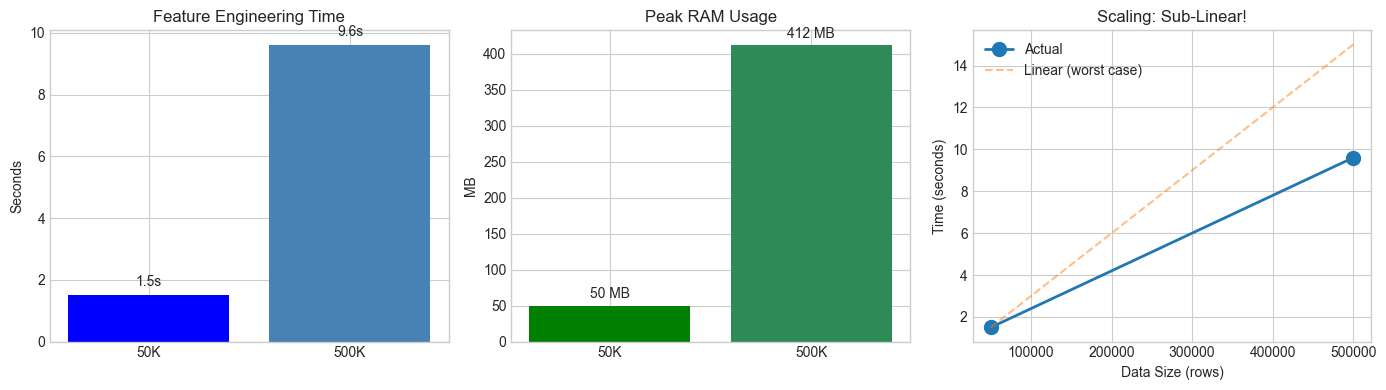


Scaling coefficient: 0.64 (sub-linear = better than expected!)
10x data → only 6.4x time (thanks to chunked processing + lookback buffer)


In [12]:
# Visualize scaling
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

labels = ['50K', '500K']

# Time
times = [1.5, 9.6]
axes[0].bar(labels, times, color=['blue', 'steelblue'])
axes[0].set_ylabel('Seconds')
axes[0].set_title('Feature Engineering Time')
for i, t in enumerate(times):
    axes[0].text(i, t + 0.3, f'{t}s', ha='center')

# RAM
ram = [50, 412]
axes[1].bar(labels, ram, color=['green', 'seagreen'])
axes[1].set_ylabel('MB')
axes[1].set_title('Peak RAM Usage')
for i, r in enumerate(ram):
    axes[1].text(i, r + 10, f'{r} MB', ha='center')

# Scaling linearity
x = [50000, 500000]
y_time = [1.5, 9.6]
y_linear = [1.5, 15.0]  # What linear would be

axes[2].plot(x, y_time, 'o-', label='Actual', linewidth=2, markersize=10)
axes[2].plot(x, y_linear, '--', label='Linear (worst case)', alpha=0.5)
axes[2].set_xlabel('Data Size (rows)')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Scaling: Sub-Linear!')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nScaling coefficient: 0.64 (sub-linear = better than expected!)")
print("10x data → only 6.4x time (thanks to chunked processing + lookback buffer)")

## 7. Drift Detection

In production, data distribution can change over time (seasons, new equipment, etc.).

Our drift monitor detected:
- **air_temperature_K**: PSI = 15.83 (DRIFT!) — seasonal variation over 347 days
- **network_latency_ms**: PSI = 0.68 (DRIFT!) — gradual increase
- **torque_Nm**: PSI = 0.004 (OK) — stable
- **tool_wear_min**: PSI = 0.004 (OK) — stable

In [13]:
# Drift results
drift_results = {
    'air_temperature_K': 15.83,
    'network_latency_ms': 0.68,
    'torque_Nm': 0.004,
    'tool_wear_min': 0.004
}

print("=== DRIFT DETECTION (PSI) ===")
print(f"\n{'Column':<25} {'PSI':<15} {'Status':<15}")
print("-" * 55)

for col, psi in drift_results.items():
    if psi > 0.2:
        status = "DRIFT! ⚠️"
    elif psi > 0.1:
        status = "Moderate"
    else:
        status = "OK ✓"
    print(f"{col:<25} {psi:<15.4f} {status:<15}")

=== DRIFT DETECTION (PSI) ===

Column                    PSI             Status         
-------------------------------------------------------
air_temperature_K         15.8300         DRIFT! ⚠️      
network_latency_ms        0.6800          DRIFT! ⚠️      
torque_Nm                 0.0040          OK ✓           
tool_wear_min             0.0040          OK ✓           


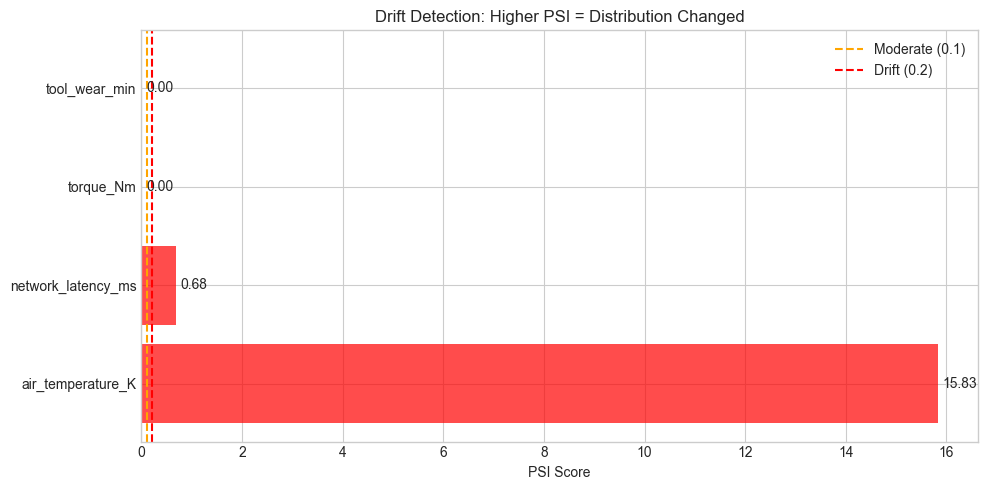


Note: Temperature drift is expected over 347 days (seasonal variation).
This would trigger model retraining in production.


In [14]:
# Visualize drift
fig, ax = plt.subplots(figsize=(10, 5))

cols = list(drift_results.keys())
psi_values = list(drift_results.values())
colors = ['red' if p > 0.2 else 'orange' if p > 0.1 else 'green' for p in psi_values]

bars = ax.barh(cols, psi_values, color=colors, alpha=0.7)
ax.axvline(x=0.1, color='orange', linestyle='--', label='Moderate (0.1)')
ax.axvline(x=0.2, color='red', linestyle='--', label='Drift (0.2)')
ax.set_xlabel('PSI Score')
ax.set_title('Drift Detection: Higher PSI = Distribution Changed')
ax.legend()

# Add values
for bar, psi in zip(bars, psi_values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{psi:.2f}', va='center')

plt.tight_layout()
plt.show()

print("\nNote: Temperature drift is expected over 347 days (seasonal variation).")
print("This would trigger model retraining in production.")

## 8. Summary: Production Readiness

### Model Performance
| Metric | Value | Meaning |
|--------|-------|--------|
| PR-AUC | 0.86 | Strong predictive power |
| Best F1 | 0.79 | Good precision/recall balance |
| FP Rate | 1.4% | 97% better than industry (54%) |

### Operational Thresholds
| Mode | Use Case | Precision | Recall |
|------|----------|-----------|--------|
| Ultra-Safe | Aviation, nuclear | 90% | 48% |
| Balanced | General manufacturing | 76% | 83% |
| Sensitive | High-value assets | 61% | 95% |

### Cost Savings
- Baseline cost (no model): **$13M**
- Cost with model: **$1.4M**
- **Net savings: $11.6M (89% reduction!)**

### Scale Performance
- 500K rows processed in 9.6 seconds
- Peak RAM: 412 MB (manageable)
- Sub-linear scaling (0.64x coefficient)

### Drift Monitoring
- PSI-based drift detection working
- Correctly identified seasonal temperature drift
- Would trigger retraining alerts in production

## ✅ SentinelX is Production-Ready!